EXAMEN TEORICO

Objetivo:
Implementar un módulo de Inteligencia de Negocios que transforme datos transaccionales brutos
en información estratégica accionable, calculando KPIs y visualizándolos en un Dashboard para
toma de decisiones de precios e inversión en el sector inmobiliario.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [4]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv('real_estate_ecuador_200k.csv')
df.head()

Saving real_estate_ecuador_200k.csv to real_estate_ecuador_200k (1).csv


,Titulo,Precio,Provincia,Lugar,Num. dormitorios,Num. banos,Area,Num. garages
0,Rento Suite 75 metros sector Republica del Sal...,395.66,Pichincha,"Pichincha, Av. Portugal & Av República de El S...",1.0,2.0,65,1.0
1,“Rento departamento en sector la Carolina”,773.69,Pichincha,"Pichincha, Catalina de Aldaz & Av. Portugal, Q...",2.0,2.0,88,1.0
2,Se Renta Amplio Departamento en el Sector de l...,616.94,Pichincha,"Pichincha, Marcos Jofre, Quito, Ecuador",4.0,4.0,214,1.0
3,Hermoso departamento de arriendo de oportunida...,286.69,Pichincha,"Pichincha, De la Prensa Y del Maestro, Quito, ...",2.0,2.0,98,1.0
4,"EN RENTA DEPARTAMENTO, CONJUNTO DIVINO NIÑO",131.54,Pichincha,"Pichincha, Turubamaba, Ecuador",3.0,2.0,53,NaN


In [6]:
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Titulo            200000 non-null  object 
 1   Precio            200000 non-null  float64
 2   Provincia         200000 non-null  object 
 3   Lugar             200000 non-null  object 
 4   Num. dormitorios  146845 non-null  float64
 5   Num. banos        165015 non-null  float64
 6   Area              200000 non-null  int64  
 7   Num. garages      142163 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 12.2+ MB


,Titulo,Precio,Provincia,Lugar,Num. dormitorios,Num. banos,Area,Num. garages
0,Rento Suite 75 metros sector Republica del Sal...,395.66,Pichincha,"Pichincha, Av. Portugal & Av República de El S...",1.0,2.0,65,1.0
1,“Rento departamento en sector la Carolina”,773.69,Pichincha,"Pichincha, Catalina de Aldaz & Av. Portugal, Q...",2.0,2.0,88,1.0
2,Se Renta Amplio Departamento en el Sector de l...,616.94,Pichincha,"Pichincha, Marcos Jofre, Quito, Ecuador",4.0,4.0,214,1.0
3,Hermoso departamento de arriendo de oportunida...,286.69,Pichincha,"Pichincha, De la Prensa Y del Maestro, Quito, ...",2.0,2.0,98,1.0
4,"EN RENTA DEPARTAMENTO, CONJUNTO DIVINO NIÑO",131.54,Pichincha,"Pichincha, Turubamaba, Ecuador",3.0,2.0,53,NaN


#**a. Perspectiva Financiera.**


KPL 1: PRECIO PROMEDIO DE ALQUILER (TOTAL Y POR CIUDAD)

In [14]:
#precio promedio general
precioPromedio = df["Precio"].mean()
print("--Precio promedio total: --")
print(precioPromedio)

#precio por ciudad
precioPorCiudad = df.groupby("Lugar")["Precio"].mean()
print(--"Precio promeido por ciudad: --")
print(precioPorCiudad)


Precio promedio total: 
732.3514613499999
Precio promeido por ciudad: 
Lugar
Cotopaxi, Latacunga, Cotopaxi, Ecuador                 3697.685799
Cotopaxi, Latacunga, Ecuador                            118.854358
El Oro, El Cambio, Machala, Ecuador                     124.256523
El Oro, Parroquia El Cambio, Machala                    124.458032
Esmeraldas, Av. Club del Pacífico, Tonsupa, Ecuador     508.493561
                                                          ...     
Pichincha, Whymper, Quito, Ecuador                      554.577541
Pichincha, Yaruquí, Quito, Ecuador                      450.745025
Pichincha, iñaquito                                     549.872578
Pichincha, poceano quito                                448.424332
Santa Elena, Chanduy, Ecuador                             8.968586
Name: Precio, Length: 305, dtype: float64


KPI 2: COSTO PROMEDIO POR METRO CUADRADO

In [16]:
df["Costo_m2"] = df["Precio"]/df["Area"]
costoPromedio = df["Costo_m2"].mean()
print("--Costo promedio por metro cuadrado: --")
print(costoPromedio)

--Costo promedio por metro cuadrado: --
5.894463987006148


KPI 3: RENGO DE PRECIOS (MIN/,AX/MEDIA) POR PROVINCIA

In [17]:
resumen = df.groupby("Lugar")["Precio"].agg(["min", "max", "mean"])
print("--Rengo de precios por provincia: --")
print(resumen)


--Rengo de precios por provincia: --
                                                        min      max  \
Lugar                                                                  
Cotopaxi, Latacunga, Cotopaxi, Ecuador              3027.29  4557.66   
Cotopaxi, Latacunga, Ecuador                          94.47   147.98   
El Oro, El Cambio, Machala, Ecuador                   98.42   154.52   
El Oro, Parroquia El Cambio, Machala                  99.93   155.03   
Esmeraldas, Av. Club del Pacífico, Tonsupa, Ecu...   401.44   620.53   
...                                                     ...      ...   
Pichincha, Whymper, Quito, Ecuador                   437.47   673.42   
Pichincha, Yaruquí, Quito, Ecuador                   364.29   552.85   
Pichincha, iñaquito                                  437.70   674.27   
Pichincha, poceano quito                             355.68   546.73   
Santa Elena, Chanduy, Ecuador                          7.22    11.03   

                          

# **b. Perspectiva de Producto.**

# i. Distribución por Tipo de Propiedad: Conteo de registros por Tipo
(Casa, Departamento, Suite, Local Comercial, etc).


In [65]:
def tipo(titulo):
    titulo = str(titulo).lower()

    if "casa" in titulo:
        return "Casa"
    elif "departamento" in titulo:
        return "Departamento"
    elif "suite" in titulo:
        return "Suite"
    elif "local" in titulo:
        return "Local Comercial"
    else:
        return "Otro"

df["Tipo"] = df["Titulo"].apply(tipo)

print("Cantidad de propiedades por tipo:")
print(df["Tipo"].value_counts())

Cantidad de propiedades por tipo:
Tipo
Departamento       86030
Otro               47461
Suite              24640
Local Comercial    21301
Casa               20568
Name: count, dtype: int64


# ii. Tamaño Promedio de Propiedades: Promedio (Area_m2) por Provincia

In [30]:

tamaño = df.groupby("Provincia")["Area"].mean()
print("--Tamaño promedio por provincia: --")
print(tamaño)



--Tamaño promedio por provincia: --
Provincia
Cotopaxi           72.428405
El Oro           5947.770492
Esmeraldas        110.380597
Guayas            103.337822
Imbabura          140.623116
Los Rios           88.953416
Manabí            199.649038
Orellana           27.992736
Pichincha         166.801846
Santa Elena    199727.401515
Name: Area, dtype: float64


# iii. Premium por Habitación Adicional: Diferencia del precio promedio entre propiedades
de 1 habitación vs. 2 habitaciones; 2 habitaciones vs. 3, 3 vs. 4, etc

In [63]:
premium = df.groupby("Num. dormitorios")["Precio"].mean()

print("--Premium por habitación adicional: --")
print(premium)



--Premium por habitación adicional: --
Num. dormitorios
1.0      583.885983
2.0      496.737218
3.0      591.991034
4.0     1073.325486
5.0     1307.772443
6.0     1506.978765
7.0     2735.398238
8.0      847.285812
9.0      403.899535
10.0     124.559920
11.0     138.438421
Name: Precio, dtype: float64


# **c. Perspectiva Geográfica.**


# i. Top 5 Ciudades/Sectores Más Caros: Ranking descendente de Precio Promedio porubicación.

In [39]:
top5 = df.groupby("Lugar")["Precio"].mean().sort_values(ascending=False).head(5)
print("--Top 5 ciudades/sectores más caros: --")
print(top5)

--Top 5 ciudades/sectores más caros: --
Lugar
Pichincha, Avenida 10 de Agosto, Quito, Ecuador    9023.844069
Manabí, Manta, Ecuador                             6503.102091
Pichincha, La Delicia, Quito, Ecuador              4999.131409
Pichincha, Guamaní, Quito, Ecuador                 3887.606034
Cotopaxi, Latacunga, Cotopaxi, Ecuador             3697.685799
Name: Precio, dtype: float64


# ii. Concentración de la Oferta: Conteo de propiedades por Provincia o Ciudad.


In [41]:
oferta = df["Provincia"].value_counts()

print("--Concentracion de oferta: --")
print(oferta)

--Concentracion de oferta: --
Provincia
Pichincha      180673
Guayas          13960
Los Rios         1288
Cotopaxi          859
Esmeraldas        804
El Oro            793
Manabí            416
Orellana          413
Imbabura          398
Santa Elena       396
Name: count, dtype: int64


# **d. Segmentación de Mercado (Económico / Medio / Lujo):**


In [61]:
q1 =df["Precio"].quantile(0.25)
q3 = df["Precio"].quantile(0.75)

def segmento(precio):
  if precio < q1:
    return "Economico"
  elif precio > q3:
        return "De lujo"
  else:
            return "Medio"

df["Tipo de Inmueble"] = df["Precio"].apply(segmento)
df.head()



,Titulo,Precio,Provincia,Lugar,Num. dormitorios,Num. banos,Area,Num. garages,Costo_m2,Tipo,Tipo de Inmueble
0,Rento Suite 75 metros sector Republica del Sal...,395.66,Pichincha,"Pichincha, Av. Portugal & Av República de El S...",1.0,2.0,65,1.0,6.087077,Suite,Medio
1,“Rento departamento en sector la Carolina”,773.69,Pichincha,"Pichincha, Catalina de Aldaz & Av. Portugal, Q...",2.0,2.0,88,1.0,8.791932,None,De lujo
2,Se Renta Amplio Departamento en el Sector de l...,616.94,Pichincha,"Pichincha, Marcos Jofre, Quito, Ecuador",4.0,4.0,214,1.0,2.882897,None,Medio
3,Hermoso departamento de arriendo de oportunida...,286.69,Pichincha,"Pichincha, De la Prensa Y del Maestro, Quito, ...",2.0,2.0,98,1.0,2.925408,None,Economico
4,"EN RENTA DEPARTAMENTO, CONJUNTO DIVINO NIÑO",131.54,Pichincha,"Pichincha, Turubamaba, Ecuador",3.0,2.0,53,NaN,2.481887,None,Economico


# **e. Dashboard**

# i. Total de propiedades


In [47]:
print("--Total de propiedades: --", len(df))

--Total de propiedades: -- 200000


# ii. Gráfico de barras de Precio promedio de alquiler (General y por Ciudad)


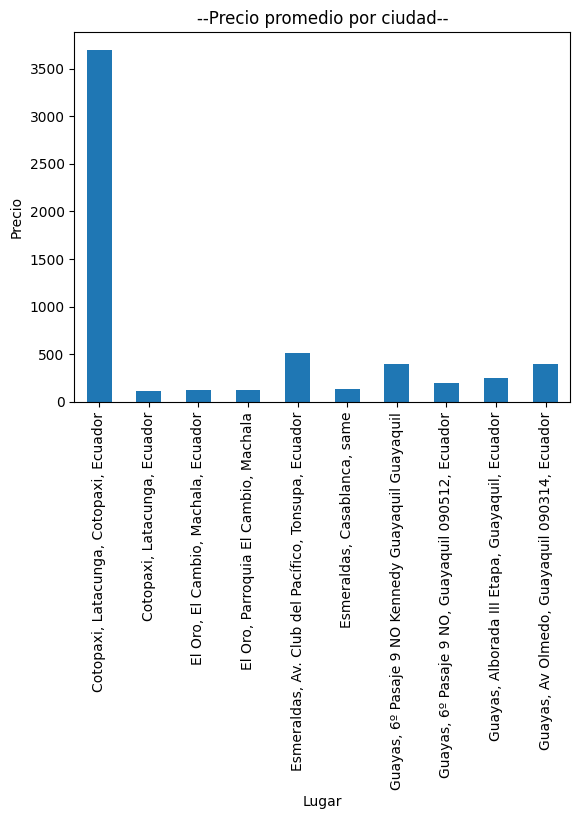

In [48]:
precioPorCiudad.head(10).plot(kind = "bar")
plt.title("--Precio promedio por ciudad--")

plt.ylabel("Precio")
plt.show()

# iii. Gráfico de dispersión de la relación entre Área y Precio


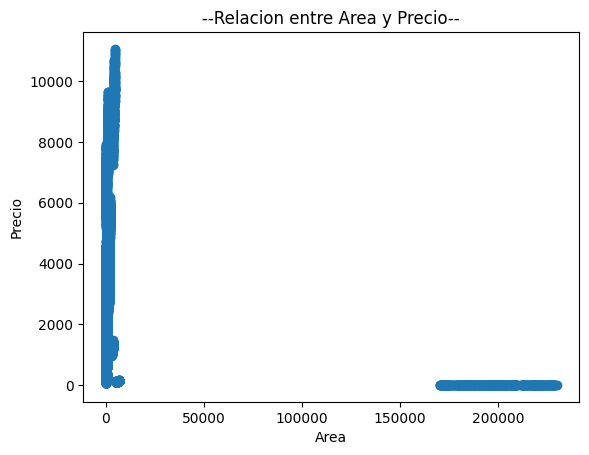

In [49]:
plt.scatter(df["Area"], df["Precio"])
plt.title("--Relacion entre Area y Precio--")
plt.xlabel("Area")
plt.ylabel("Precio")
plt.show()

# iv. Gráfico de pastel de conteo de registros por Tipo
(Casa, Departamento, Suite, Local
Comercial).

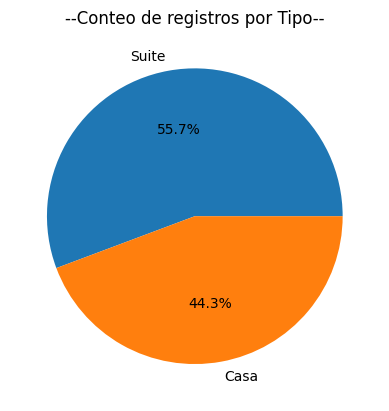

In [50]:
df["Tipo"].value_counts().plot(kind = "pie", autopct = "%1.1f%%")
plt.title("--Conteo de registros por Tipo--")
plt.ylabel("")
plt.show()

# v. Gráfico de Premium por Habitación Adicional

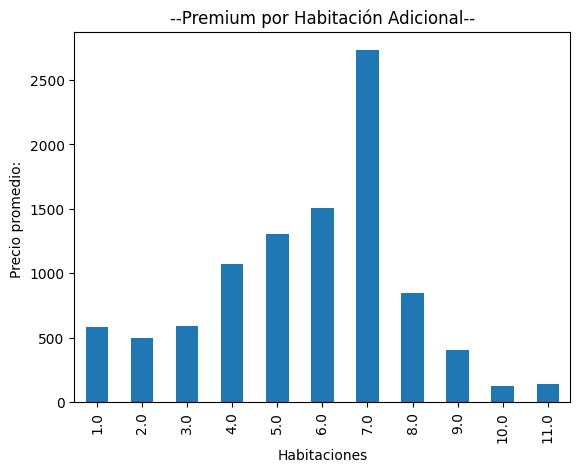

In [64]:
premium.plot(kind = "bar")
plt.title("--Premium por Habitación Adicional--")
plt.xlabel("Habitaciones")
plt.ylabel("Precio promedio: ")
plt.show()